In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:

# Load, parse dates, and set the index all in one step:
df_rates = pd.read_csv('data/raw_exchange_rates.csv', parse_dates=['date'], index_col='date')


# Preview the first 5 rows of the dataset
df_rates.head()

,usd_to_ngn_rate,ngn_to_usd_rate
date,,
2014-11-07,165.75,0.006033
2014-11-10,168.30,0.005942
2014-11-11,168.50,0.005935
2014-11-12,169.55,0.005898
2014-11-13,172.30,0.005804


## Verify if there are missing dates (e.g. weekends) using .asfreq('D').

In [41]:
# 1. Store the original number of records
original_count = len(df_rates)

# 2. Re-index to daily frequency ('D')
df_daily = df_rates.asfreq('D')

# 3. Calculate how many rows were added
new_count = len(df_daily)
dates_added = new_count - original_count

# 4. Check for missing values (NaN) introduced by the re-indexing
null_counts = df_daily.isnull().sum()

print(f"Original trading-day records: {original_count}")
print(f"New daily calendar records: {new_count}")
print(f"Number of missing dates identified (weekends/holidays): {dates_added}")
print("\nMissing values (NaN) per column after daily re-indexing:")
print(null_counts)

# Preview a sample showing the newly introduced weekend NaN rows (e.g., Saturday & Sunday)
df_daily.head(10)


Original trading-day records: 2763
New daily calendar records: 4249
Number of missing dates identified (weekends/holidays): 1486

Missing values (NaN) per column after daily re-indexing:
usd_to_ngn_rate    1486
ngn_to_usd_rate    1486
dtype: int64


,usd_to_ngn_rate,ngn_to_usd_rate
date,,
2014-11-07,165.75,0.006033
2014-11-08,NaN,NaN
2014-11-09,NaN,NaN
2014-11-10,168.30,0.005942
2014-11-11,168.50,0.005935
2014-11-12,169.55,0.005898
2014-11-13,172.30,0.005804
2014-11-14,171.05,0.005846
2014-11-15,NaN,NaN


## Implement forward-fill (.ffill()) to handle weekend gap filling.

In [42]:
# 1. Forward-fill the missing rates in the daily DataFrame
df_daily = df_daily.ffill()

# 2. Check if there are any remaining null values
remaining_nulls = df_daily.isnull().sum()

print("Null values remaining after forward-fill:")
print(remaining_nulls)

# 3. Preview the same sample to confirm that NaN values have been replaced
df_daily.head(10)


Null values remaining after forward-fill:
usd_to_ngn_rate    0
ngn_to_usd_rate    0
dtype: int64


,usd_to_ngn_rate,ngn_to_usd_rate
date,,
2014-11-07,165.75,0.006033
2014-11-08,165.75,0.006033
2014-11-09,165.75,0.006033
2014-11-10,168.30,0.005942
2014-11-11,168.50,0.005935
2014-11-12,169.55,0.005898
2014-11-13,172.30,0.005804
2014-11-14,171.05,0.005846
2014-11-15,171.05,0.005846


## Calculate daily percentage returns using .pct_change().

In [43]:
# Calculate daily percentage returns for the USD/NGN exchange rate
df_daily['daily_return'] = df_daily['usd_to_ngn_rate'].pct_change()

# Preview the head to verify the new column
df_daily.head()


,usd_to_ngn_rate,ngn_to_usd_rate,daily_return
date,,,
2014-11-07,165.75,0.006033,NaN
2014-11-08,165.75,0.006033,0.000000
2014-11-09,165.75,0.006033,0.000000
2014-11-10,168.30,0.005942,0.015385
2014-11-11,168.50,0.005935,0.001188


## Compute the 30-day Simple Moving Average (SMA) of the rate.

In [45]:
# Compute the 30-day Simple Moving Average
df_daily['sma_30'] = df_daily['usd_to_ngn_rate'].rolling(window=30).mean()

# Preview the output to verify the new column
df_daily.tail()


,usd_to_ngn_rate,ngn_to_usd_rate,daily_return,sma_30
date,,,,
2026-06-21,1358.89,0.000736,0.000000,1363.509333
2026-06-22,1366.23,0.000732,0.005401,1363.320000
2026-06-23,1366.78,0.000732,0.000403,1363.149000
2026-06-24,1374.20,0.000728,0.005429,1363.278000
2026-06-25,1377.61,0.000726,0.002481,1363.424333


## Compute the 90-day Simple Moving Average (SMA) of the rate.

In [46]:
# Compute the 90-day Simple Moving Average
df_daily['sma_90'] = df_daily['usd_to_ngn_rate'].rolling(window=90).mean()

# Preview the output to verify the new column
df_daily.tail()

,usd_to_ngn_rate,ngn_to_usd_rate,daily_return,sma_30,sma_90
date,,,,,
2026-06-21,1358.89,0.000736,0.000000,1363.509333,1365.074222
2026-06-22,1366.23,0.000732,0.005401,1363.320000,1364.931556
2026-06-23,1366.78,0.000732,0.000403,1363.149000,1364.732778
2026-06-24,1374.20,0.000728,0.005429,1363.278000,1364.630333
2026-06-25,1377.61,0.000726,0.002481,1363.424333,1364.574778


## Compute 30-day rolling standard deviation of daily returns.

In [47]:
# Compute the 30-day rolling standard deviation of daily returns
df_daily['rolling_vol_30d'] = df_daily['daily_return'].rolling(window=30).std()
# Preview the output to verify the new column
df_daily.tail()

,usd_to_ngn_rate,ngn_to_usd_rate,daily_return,sma_30,sma_90,rolling_vol_30d
date,,,,,,
2026-06-21,1358.89,0.000736,0.000000,1363.509333,1365.074222,0.001119
2026-06-22,1366.23,0.000732,0.005401,1363.320000,1364.931556,0.001531
2026-06-23,1366.78,0.000732,0.000403,1363.149000,1364.732778,0.001534
2026-06-24,1374.20,0.000728,0.005429,1363.278000,1364.630333,0.001825
2026-06-25,1377.61,0.000726,0.002481,1363.424333,1364.574778,0.001840


## Annualize the 30-day rolling standard deviation by multiplying by np.sqrt(252).

In [48]:
# Annualize the 30-day rolling volatility (assuming 252 trading days in a year)
df_daily['annualized_vol_30d'] = df_daily['rolling_vol_30d'] * np.sqrt(252)

## Handle the missing NaN values created by the rolling windows using .fillna() or .dropna().

In [49]:
# 1. Get the sum of missing values for each column before dropping
print("Missing values per column BEFORE dropping:")
print(df_daily.isnull().sum())

# 2. Drop the rows containing NaN values
df_clean = df_daily.dropna()

# 3. Verify that the clean DataFrame has no missing values remaining
print("\nMissing values per column AFTER dropping:")
print(df_clean.isnull().sum())


Missing values per column BEFORE dropping:
usd_to_ngn_rate        0
ngn_to_usd_rate        0
daily_return           1
sma_30                29
sma_90                89
rolling_vol_30d       30
annualized_vol_30d    30
dtype: int64

Missing values per column AFTER dropping:
usd_to_ngn_rate       0
ngn_to_usd_rate       0
daily_return          0
sma_30                0
sma_90                0
rolling_vol_30d       0
annualized_vol_30d    0
dtype: int64


## Downsample (resample) daily data to quarterly averages using .resample('QE').mean() to align with corporate reporting dates.

In [50]:
# Downsample the clean daily data to quarterly averages using the new 'QE' alias
df_quarterly = df_clean.resample('QE').mean()
# Preview the quarterly averages
df_quarterly.head()

,usd_to_ngn_rate,ngn_to_usd_rate,daily_return,sma_30,sma_90,rolling_vol_30d,annualized_vol_30d
date,,,,,,,
2015-03-31,199.528569,0.005013,0.000854,196.790409,188.742041,0.006827,0.108376
2015-06-30,198.886043,0.005028,-0.000005,198.929428,198.447517,0.001196,0.018994
2015-09-30,198.811522,0.005030,-0.000048,198.830304,198.858914,0.001382,0.021935
2015-12-31,198.849022,0.005029,0.000056,198.834409,198.822717,0.001624,0.025777
2016-03-31,198.823516,0.005030,-0.000035,198.859106,198.841962,0.001603,0.025453


In [51]:
# Check for any NaNs introduced in the quarterly DataFrame
print("Null values in quarterly DataFrame:")
print(df_quarterly.isnull().sum())


Null values in quarterly DataFrame:
usd_to_ngn_rate       0
ngn_to_usd_rate       0
daily_return          0
sma_30                0
sma_90                0
rolling_vol_30d       0
annualized_vol_30d    0
dtype: int64


## Integrating SQL lite to Python

In [52]:
import os
import psycopg2
from dotenv import load_dotenv

# Load database credentials from your config.env file
load_dotenv('config.env')
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME", "naira_volatility")

In [53]:
# Build connection settings
conn_args = {
    "host": DB_HOST,
    "port": DB_PORT,
    "user": DB_USER,
    "dbname": DB_NAME
}
if DB_PASSWORD and DB_PASSWORD.strip():
    conn_args["password"] = DB_PASSWORD
# Connect to the PostgreSQL server
conn = psycopg2.connect(**conn_args)

In [54]:
# Write the SQL query (e.g., Query 2 joining exchange rates and financials)
query = """
SELECT 
    f.ticker,
    f.fiscal_year,
    f.revenue AS corporate_revenue_ngn,
    f.net_profit AS corporate_net_profit_ngn,
    COALESCE(f.fx_translation_loss, 0) AS reported_fx_loss_ngn,
    e.avg_usd_to_ngn_rate,
    e.peak_annualized_volatility
FROM financial_statements f
INNER JOIN (
    SELECT 
        EXTRACT(YEAR FROM rate_date) AS yr,
        AVG(usd_to_ngn_rate) AS avg_usd_to_ngn_rate,
        MAX(annualized_vol_30d) AS peak_annualized_volatility
    FROM exchange_rates
    GROUP BY yr
) e ON f.fiscal_year = e.yr
WHERE f.ticker = 'PZN'
ORDER BY f.fiscal_year ASC;
"""

# Run the query and store the results in a Pandas DataFrame
df_analysis = pd.read_sql(query, conn)

# Preview the results
df_analysis


/var/folders/5_/2c7k7h_d2jg4m7qc2c9723wr0000gn/T/ipykernel_79147/3741008415.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_analysis = pd.read_sql(query, conn)


,ticker,fiscal_year,corporate_revenue_ngn,corporate_net_profit_ngn,reported_fx_loss_ngn,avg_usd_to_ngn_rate,peak_annualized_volatility
0,PZN,2021,8.257754e+10,1.559857e+09,0.000000e+00,397.941548,0.265416
1,PZN,2022,9.950332e+10,6.699325e+09,0.000000e+00,422.672830,0.021098
2,PZN,2023,1.139643e+11,1.434834e+10,0.000000e+00,635.766403,1.035815
3,PZN,2024,1.522493e+11,-9.031728e+10,1.579182e+11,1476.070574,1.214915
4,PZN,2025,2.126343e+11,1.006672e+10,7.784240e+09,1517.502000,0.134381


In [55]:
# Close the cursor and connection
conn.close()

## Exploratory Data Analysis & Visualization


### 1. Daily Naira/USD rate with 30-day and 90-day SMAs overlaid Chart

findfont: Failed to find font weight semibold, now using 700.


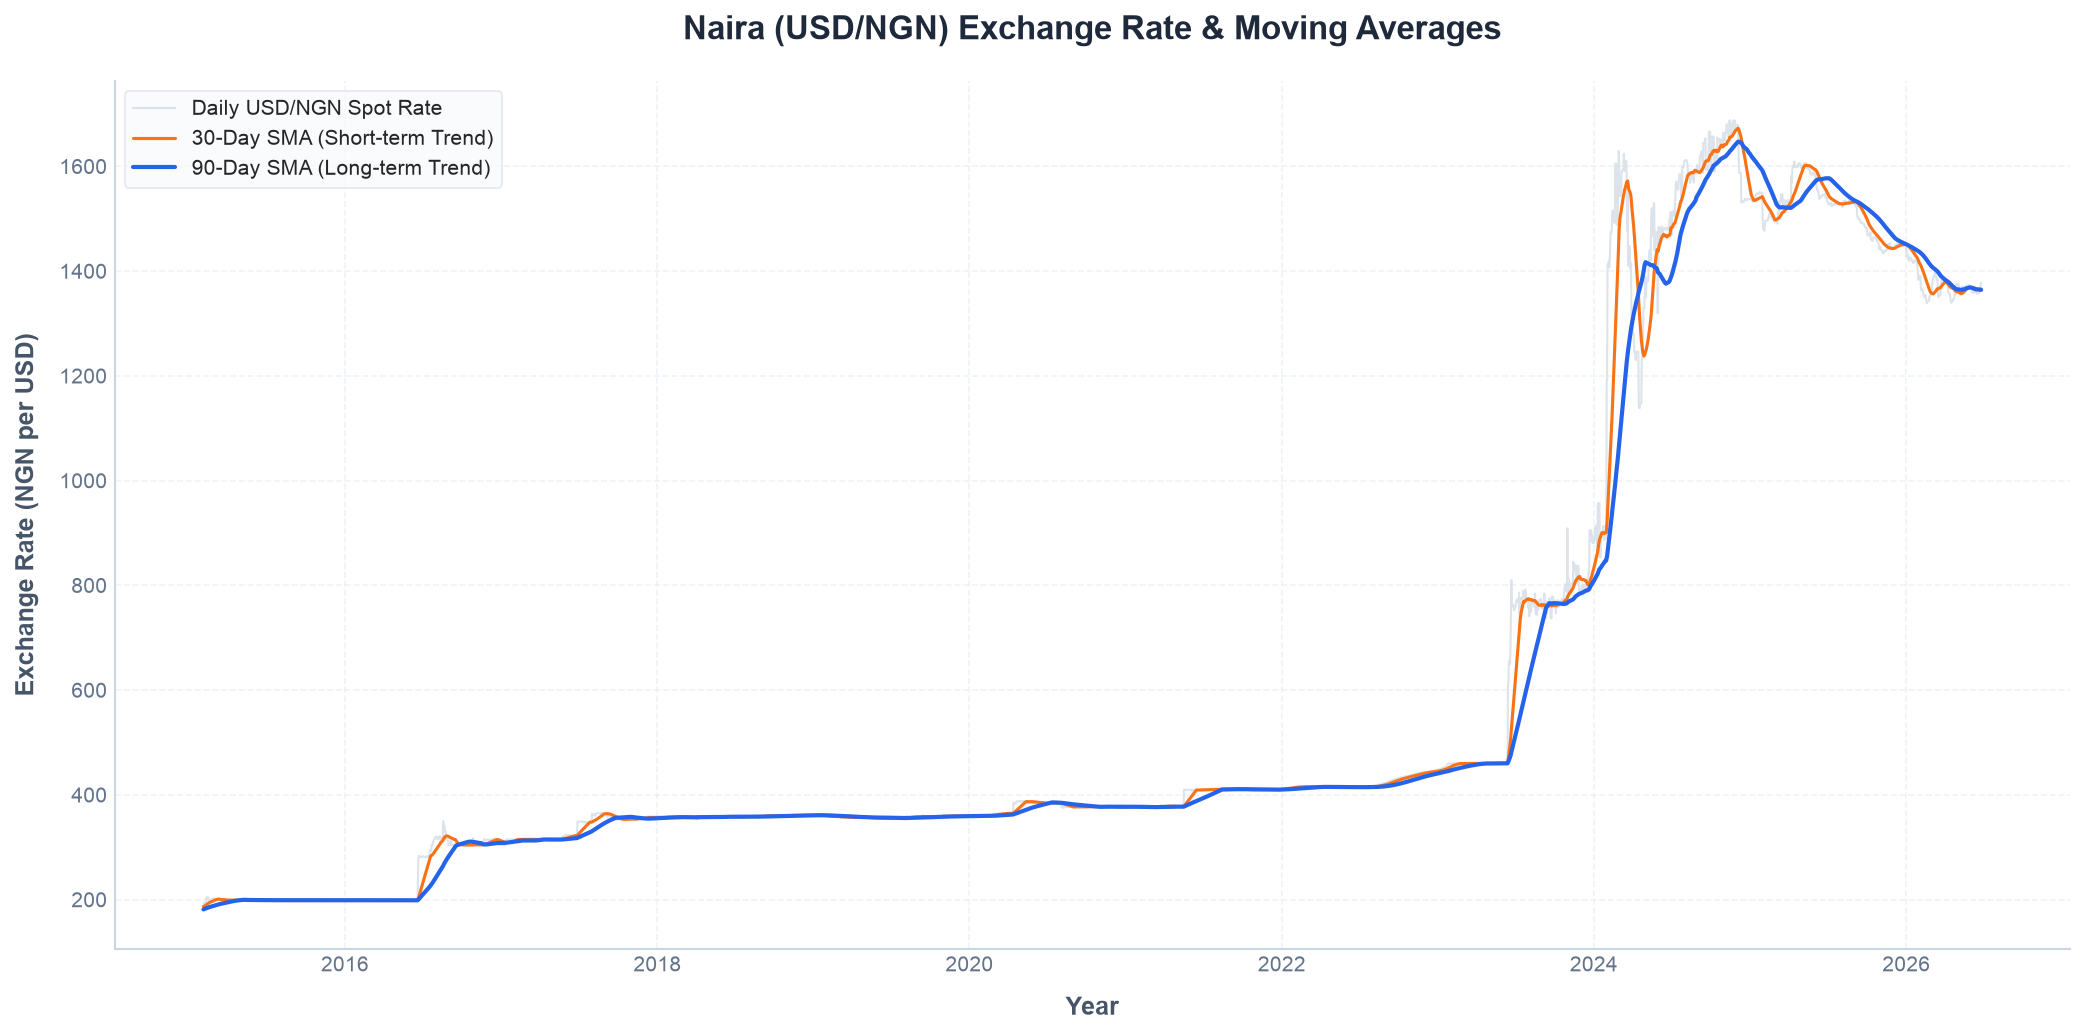

In [ ]:
# Set up a premium style and plot size
plt.style.use('seaborn-v0_8-whitegrid')  # Clean, modern layout grid
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

# Plot the raw exchange rate with low opacity so moving averages stand out
ax.plot(
    df_clean.index, 
    df_clean['usd_to_ngn_rate'], 
    label='Daily USD/NGN Spot Rate', 
    color='#cbd5e1',  # Sleek slate-gray
    linewidth=1.0, 
    alpha=0.65
)

# Plot the 30-day SMA
ax.plot(
    df_clean.index, 
    df_clean['sma_30'], 
    label='30-Day SMA (Short-term Trend)', 
    color='#f97316',  # Bright orange
    linewidth=1.5,
    linestyle='-'
)

# Plot the 90-day SMA
ax.plot(
    df_clean.index, 
    df_clean['sma_90'], 
    label='90-Day SMA (Long-term Trend)', 
    color='#2563eb',  # Royal blue
    linewidth=2.0,
    linestyle='-'
)

# Configure premium labels, title, and font hierarchy
ax.set_title(
    "Naira (USD/NGN) Exchange Rate & Moving Averages", 
    fontsize=16, 
    fontweight='bold', 
    pad=20,
    color='#1e293b'
)
ax.set_xlabel("Year", fontsize=12, labelpad=10, fontweight='semibold', color='#475569')
ax.set_ylabel("Exchange Rate (NGN per USD)", fontsize=12, labelpad=10, fontweight='semibold', color='#475569')

# Format axes and gridlines
ax.tick_params(colors='#64748b', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.5, color='#e2e8f0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.spines['bottom'].set_color('#cbd5e1')

# Add a clean legend in a safe position
ax.legend(
    loc='upper left', 
    frameon=True, 
    facecolor='#f8fafc', 
    edgecolor='#e2e8f0', 
    fontsize=10
)

plt.tight_layout()
plt.show()


### Chart Analysis: Trend and Moving Averages
* **Long-term Stability vs. Shock**: This chart displays the long-term price trajectory of the NGN/USD rate from 2014 to 2026. The flat steps between 2016 and 2023 represent periods where the Central Bank maintained a fixed peg. The sudden vertical climb starting in mid-2023 represents the abandonment of the peg and the transition to a floating currency regime.
* **SMA Lag and Momentum**: The **30-Day SMA (Orange)** and **90-Day SMA (Blue)** act as smoothed trend indicators. During the rapid devaluations of mid-2023 and early 2024, the spot rate climbed faster than the moving averages, leaving a significant gap. Once the spot rate stabilized in 2025, the moving averages caught up and merged, indicating that the rapid upward momentum of the devaluation had slowed down.

### 2. Central Bank flotation in mid-2023 Chart

/var/folders/5_/2c7k7h_d2jg4m7qc2c9723wr0000gn/T/ipykernel_79147/4006903557.py:39: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.annotate(


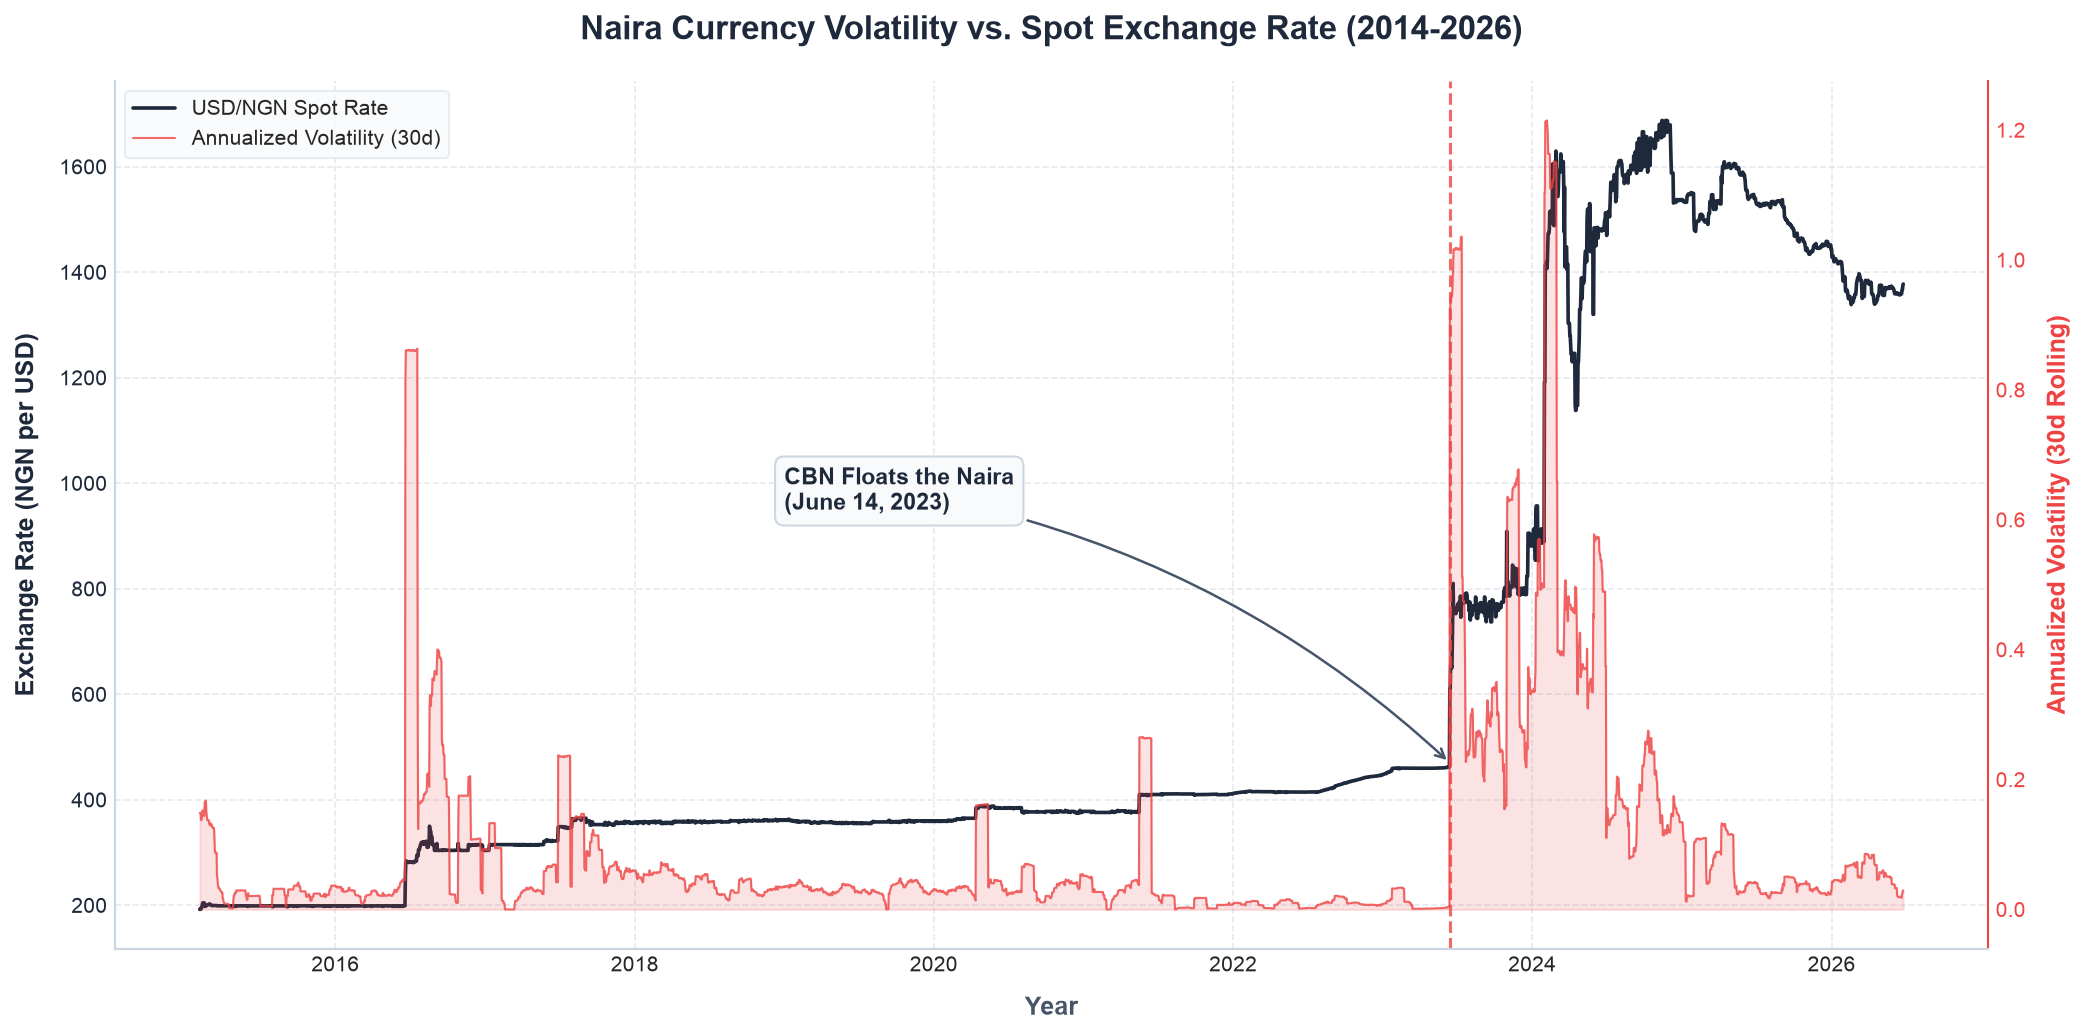

In [ ]:
# 1. Initialize the dual-axis figure layout
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=150)
ax2 = ax1.twinx()  # Share the X-axis for the right-hand Y-axis

# 2. Plot USD/NGN Exchange Rate on the LEFT Axis (solid line)
color_rate = '#1e293b'  # Dark slate
line_rate = ax1.plot(
    df_clean.index, 
    df_clean['usd_to_ngn_rate'], 
    label='USD/NGN Spot Rate', 
    color=color_rate, 
    linewidth=1.75
)

# 3. Plot Annualized 30-day Rolling Volatility on the RIGHT Axis (filled area)
color_vol = '#ef4444'  # Crimson red
area_vol = ax2.fill_between(
    df_clean.index, 
    df_clean['annualized_vol_30d'], 
    label='Annualized Volatility (30d)', 
    color=color_vol, 
    alpha=0.15  # Semi-transparent to keep the chart clean
)
line_vol = ax2.plot(
    df_clean.index, 
    df_clean['annualized_vol_30d'], 
    label='Annualized Volatility (30d)',
    color=color_vol, 
    linewidth=1.0, 
    alpha=0.8
)

# 4. Annotate Key Macroeconomic Events
# Event: June 2023 Central Bank Flotation
float_date = pd.to_datetime('2023-06-14')
ax1.axvline(float_date, color='#ef4444', linestyle='--', linewidth=1.5, alpha=0.8)

# Add text annotation with arrow pointing to the flotation event
ax1.annotate(
    "CBN Floats the Naira\n(June 14, 2023)",
    xy=(float_date, 470),          # Coordinates of the pointing tip
    xytext=(pd.to_datetime('2019-01-01'), 950), # Coordinates of the text box placement
    arrowprops=dict(
        facecolor='#1e293b', 
        arrowstyle="->", 
        connectionstyle="arc3,rad=-0.15",
        color='#475569',
        linewidth=1.2
    ),
    fontsize=11,
    fontweight='bold',
    color='#1e293b',
    bbox=dict(boxstyle="round,pad=0.4", facecolor='#f8fafc', edgecolor='#cbd5e1', alpha=0.95)
)

# 5. Labels and Titles Configuration
ax1.set_title(
    "Naira Currency Volatility vs. Spot Exchange Rate (2014-2026)", 
    fontsize=16, 
    fontweight='bold', 
    pad=20,
    color='#1e293b'
)
ax1.set_xlabel("Year", fontsize=12, labelpad=10, fontweight='semibold', color='#475569')

# Axis 1 (Left: Exchange Rate) settings
ax1.set_ylabel("Exchange Rate (NGN per USD)", fontsize=12, labelpad=10, fontweight='semibold', color=color_rate)
ax1.tick_params(axis='y', labelcolor=color_rate)
ax1.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')

# Axis 2 (Right: Volatility) settings
ax2.set_ylabel("Annualized Volatility (30d Rolling)", fontsize=12, labelpad=10, fontweight='semibold', color=color_vol)
ax2.tick_params(axis='y', labelcolor=color_vol)
ax2.grid(False)  # Turn off second grid to prevent visual interference

# Clean visual spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')
ax1.spines['right'].set_visible(False)
ax2.spines['right'].set_color(color_vol)

# 6. Combined Legend
lines = line_rate + [line_vol[0]]
labels = [l.get_label() for l in lines]
ax1.legend(
    lines, 
    labels, 
    loc='upper left', 
    frameon=True, 
    facecolor='#f8fafc', 
    edgecolor='#e2e8f0', 
    fontsize=10
)

plt.tight_layout()
plt.show()


### Chart Analysis: Volatility Shock vs. Spot Stabilization
* **The Flotation Shock (Red Line)**: Prior to the **June 14, 2023 flotation event (red dashed line)**, daily volatility was close to zero because the exchange rate was administratively pegged. Immediately following the float, market uncertainty drove annualized volatility to a peak of **121.49%** in early 2024 as the market searched for a new price equilibrium.
* **Stabilization Narrative**: The critical insight is that in 2025 and 2026, the spot exchange rate remained highly devalued (near 1,400 NGN/USD), but the **volatility collapsed back to a baseline of ~13%**. This demonstrates that the severe currency risk subsided once the market settled at its new equilibrium rate, creating a much more stable environment for local businesses.

### 3. Ratio Analysis

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


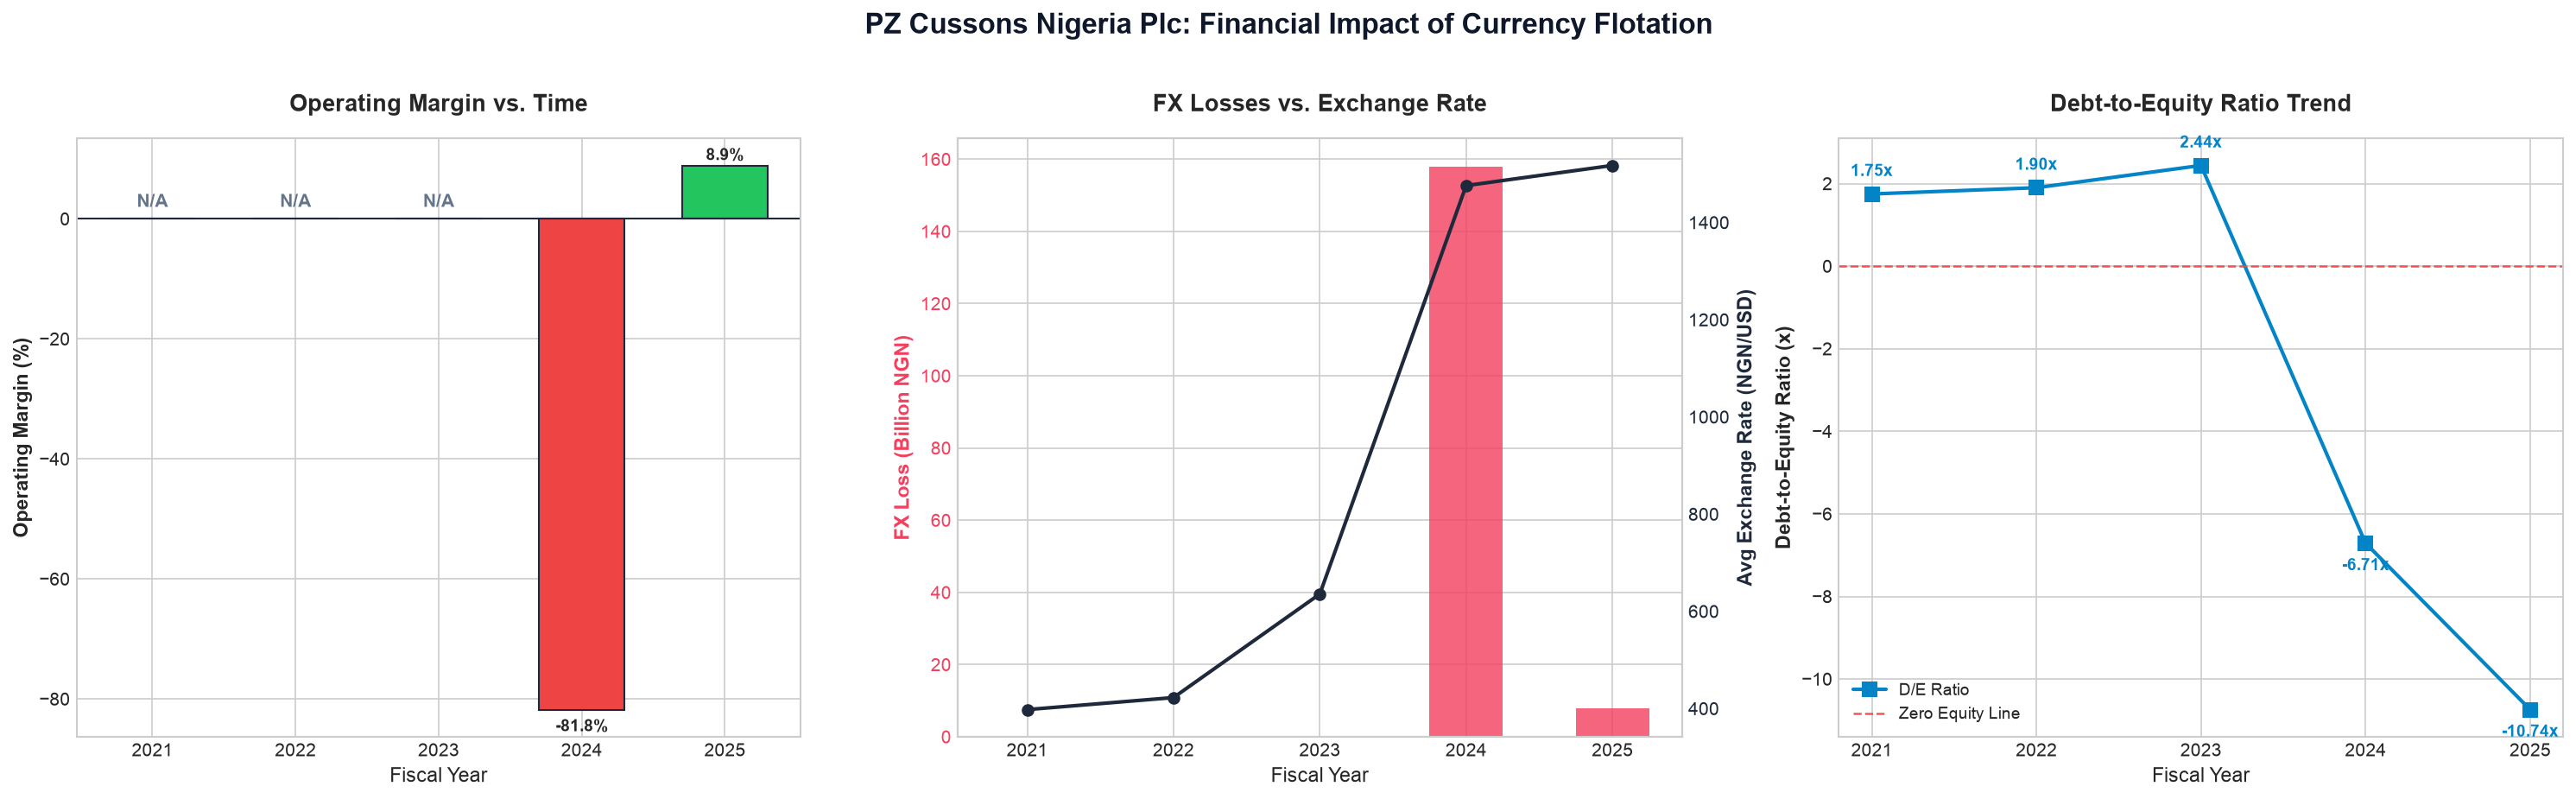

In [60]:

# 1. Load the computed ratios and merge with the database query results (for exchange rates)
df_ratios = pd.read_csv('data/pz_cussons_ratios.csv')

# Ensure df_analysis (from your previous database cell) is merged to get the average rate
df_merged = pd.merge(
    df_ratios, 
    df_analysis[['fiscal_year', 'avg_usd_to_ngn_rate']], 
    on='fiscal_year'
)

# Convert FX losses and Revenue to Billions for clean axis labels
df_merged['fx_loss_billions'] = df_merged['fx_translation_loss'] / 1e9

# Set up a 1x3 horizontal visualization panel
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# SUBPLOT 1: Operating Margin vs. Time
# ==========================================
# We use a bar chart to represent the positive vs negative margin split
years = df_merged['fiscal_year'].astype(str)
margins = df_merged['operating_margin_%'].fillna(0)  # Replace NaN with 0 for display

colors_margin = ['#94a3b8' if m == 0 else ('#ef4444' if m < 0 else '#22c55e') for m in margins]
bars = ax1.bar(years, margins, color=colors_margin, edgecolor='#1e293b', width=0.6)

ax1.axhline(0, color='#1e293b', linewidth=1.0, linestyle='-')
ax1.set_title("Operating Margin vs. Time", fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel("Operating Margin (%)", fontsize=11, fontweight='semibold')
ax1.set_xlabel("Fiscal Year", fontsize=11)
ax1.tick_params(labelsize=10)

# Add value labels on top/bottom of bars
for bar in bars:
    height = bar.get_height()
    if height != 0:
        va = 'bottom' if height > 0 else 'top'
        ax1.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3 if height > 0 else -12),
            textcoords="offset points",
            ha='center', 
            fontsize=9, 
            fontweight='bold'
        )
# Label N/A for missing historical operational rows
ax1.annotate("N/A", xy=('2021', 2), ha='center', color='#64748b', fontweight='semibold')
ax1.annotate("N/A", xy=('2022', 2), ha='center', color='#64748b', fontweight='semibold')
ax1.annotate("N/A", xy=('2023', 2), ha='center', color='#64748b', fontweight='semibold')


# ==========================================
# SUBPLOT 2: FX Losses vs. Avg USD/NGN Rates (Dual Axis)
# ==========================================
# Left axis: FX losses in Billions (Bars)
bars_fx = ax2.bar(
    years, 
    df_merged['fx_loss_billions'].fillna(0), 
    color='#f43f5e', 
    alpha=0.8, 
    label='FX Translation Loss', 
    width=0.5
)
ax2.set_ylabel("FX Loss (Billion NGN)", color='#f43f5e', fontsize=11, fontweight='semibold')
ax2.tick_params(axis='y', labelcolor='#f43f5e')

# Right axis: Average USD/NGN Exchange Rate (Line)
ax2_twin = ax2.twinx()
line_rate = ax2_twin.plot(
    years, 
    df_merged['avg_usd_to_ngn_rate'], 
    color='#1e293b', 
    marker='o', 
    linewidth=2.0, 
    label='Avg USD/NGN Rate'
)
ax2_twin.set_ylabel("Avg Exchange Rate (NGN/USD)", color='#1e293b', fontsize=11, fontweight='semibold')
ax2_twin.tick_params(axis='y', labelcolor='#1e293b')
ax2_twin.grid(False)

ax2.set_title("FX Losses vs. Exchange Rate", fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("Fiscal Year", fontsize=11)


# ==========================================
# SUBPLOT 3: Debt-to-Equity Ratio Trend
# ==========================================
# A line chart shows the structural solvency trend
de_ratio = df_merged['debt_to_equity_ratio']
ax3.plot(years, de_ratio, color='#0284c7', marker='s', markersize=8, linewidth=2.0, label='D/E Ratio')

# Reference line at zero: separation of positive and negative equity
ax3.axhline(0, color='#ef4444', linestyle='--', linewidth=1.2, alpha=0.9, label='Zero Equity Line')

ax3.set_title("Debt-to-Equity Ratio Trend", fontsize=13, fontweight='bold', pad=15)
ax3.set_ylabel("Debt-to-Equity Ratio (x)", fontsize=11, fontweight='semibold')
ax3.set_xlabel("Fiscal Year", fontsize=11)
ax3.legend(loc='lower left', fontsize=9)
ax3.tick_params(labelsize=10)

# Add values above/below points
for i, val in enumerate(de_ratio):
    ax3.annotate(
        f"{val:.2f}x",
        xy=(i, val),
        xytext=(0, 10 if val > 0 else -15),
        textcoords="offset points",
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#0284c7'
    )

# Clean up layout and display
plt.suptitle(
    "PZ Cussons Nigeria Plc: Financial Impact of Currency Flotation", 
    fontsize=16, 
    fontweight='bold', 
    y=1.02, 
    color='#0f172a'
)
plt.tight_layout()
plt.show()


### Chart Analysis: Microeconomic Impact on PZ Cussons Nigeria Plc
The three-panel visualization maps out the structural financial damage caused by the Naira flotation:
1. **Panel 1: Operating Margin Squeeze**: In 2024, the company recorded a devastating **-81.8% operating margin** due to the N157.9 Billion FX write-off. In 2025, because volatility subsided and the currency stabilized, FX write-offs shrank, allowing the company to recover to a positive **+8.9% operating margin**.
2. **Panel 2: FX Loss vs. Exchange Rate**: This panel clearly shows the link between the average exchange rate hike (jumping from 635 to 1,476 NGN/USD) and the N157.9 Billion FX loss in 2024. In 2025, even though the average rate grew slightly to 1,517 NGN/USD, the lack of daily volatility reduced the write-off to N7.78 Billion.
3. **Panel 3: Balance Sheet Insolvency (D/E Trend)**: Shows the company's leverage ratio rising under the peg (1.75x in 2021 to 2.44x in 2023). In 2024 and 2025, the ratio **flips to negative values (-6.71x and -10.74x)** because the N90 Billion net loss wiped out all of the company's capital reserves, leaving them with negative shareholder equity (assets smaller than liabilities).